In [7]:
# Setup: imports and paths
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project layout
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets" / "eda"
REPORT_DIR = PROJECT_ROOT / "report"

# Ensure directories exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset path
DATA_PATH = DATA_DIR / "processed" / "amazon_conversations.csv"
print("✅ Setup complete. Project root:", PROJECT_ROOT)
print("📂 Data path:", DATA_PATH)

✅ Setup complete. Project root: d:\Programming\PJCT\Hiver AI Support Agent
📂 Data path: d:\Programming\PJCT\Hiver AI Support Agent\data\processed\amazon_conversations.csv


# Phase 3 — EDA & Intent Discovery Preparation
This notebook performs a production-quality exploratory data analysis on the reconstructed Amazon conversations and prepares a clean customer corpus for intent discovery.

## Section 1 — Dataset Loading
Load `data/processed/amazon_conversations.csv` and show dataset summary.

In [8]:
# Section 1 — Load dataset (uses setup cell variables)
print("📁 Project Root:", PROJECT_ROOT)
print("📂 Dataset Path:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

# Load dataset
df = pd.read_csv(DATA_PATH)

print("\n✅ Dataset Loaded Successfully!")
print("📊 Shape:", df.shape)

df.head()

📁 Project Root: d:\Programming\PJCT\Hiver AI Support Agent
📂 Dataset Path: d:\Programming\PJCT\Hiver AI Support Agent\data\processed\amazon_conversations.csv

✅ Dataset Loaded Successfully!
📊 Shape: (82556, 8)


,conversation_id,root_tweet_id,conversation,message_count,customer_message_count,amazon_message_count,first_tweet_id,last_tweet_id
0,AMZ_000001,272,Customer:\namazonのfireTVstickが見れない😢\n\nAmazon:...,7,4,3,272,275
1,AMZ_000002,325,Customer:\namazonプライムビデオ、再生エラーが多いです\n\nAmazon:...,2,1,1,325,324
2,AMZ_000003,617,Customer:\nWay to drop the ball on customer se...,5,3,2,617,619
3,AMZ_000004,621,Customer:\n@115823 I want my amazon payments a...,2,1,1,621,620
4,AMZ_000005,624,"Customer:\n@115825 also, beim Addams Family-Fi...",4,2,2,624,625


## Section 2 — Missing Value Analysis
Compute missing counts and percentages.

In [9]:
# Section 2 — Missing Value Analysis
missing = df.isna().sum().reset_index()
missing.columns = ['column', 'missing_count']
missing['missing_percent'] = missing['missing_count'] / len(df) * 100
print('✅ Missing value analysis')
display(missing)
passes = missing['missing_count'].sum() == 0
print('PASS' if passes else 'FAIL')

✅ Missing value analysis


,column,missing_count,missing_percent
0,conversation_id,0,0.0
1,root_tweet_id,0,0.0
2,conversation,0,0.0
3,message_count,0,0.0
4,customer_message_count,0,0.0
5,amazon_message_count,0,0.0
6,first_tweet_id,0,0.0
7,last_tweet_id,0,0.0


PASS


## Section 3 — Conversation Length Analysis
Use `message_count` to analyse conversation sizes.

In [10]:
# Section 3 — Setup plotting imports (already imported in setup but keep local alias if needed)
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

📊 Conversation message_count statistics:
count    82556.000000
mean         4.530767
std          5.319768
min          2.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        448.000000
Name: message_count, dtype: float64


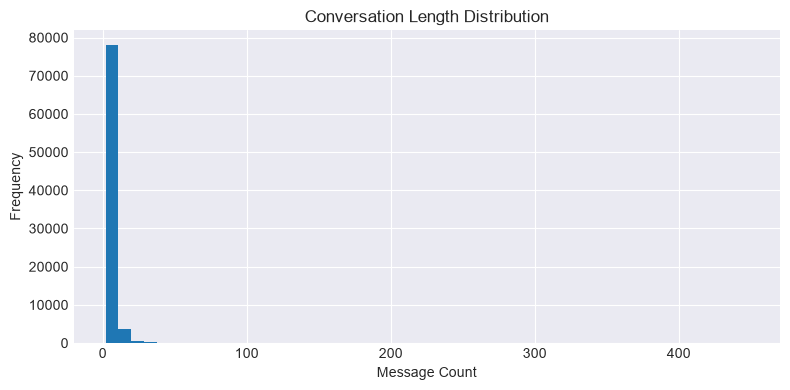


Percentiles:
0.50     3.0
0.75     5.0
0.90     8.0
0.95    11.0
0.99    21.0
Name: message_count, dtype: float64

Top 10 longest conversations:
      conversation_id  message_count
78         AMZ_000079            448
13097      AMZ_013098            448
50240      AMZ_050241            425
346        AMZ_000347            218
30132      AMZ_030133            207
36820      AMZ_036821            161
21962      AMZ_021963            141
8239       AMZ_008240            139
27715      AMZ_027716            128
27395      AMZ_027396            124

Top 10 shortest conversations:
      conversation_id  message_count
82551      AMZ_082552              2
82549      AMZ_082550              2
82548      AMZ_082549              2
82547      AMZ_082548              2
82546      AMZ_082547              2
82545      AMZ_082546              2
82544      AMZ_082545              2
82542      AMZ_082543              2
82541      AMZ_082542              2
82539      AMZ_082540              2


In [11]:
# Conversation Length Analysis
print('📊 Conversation message_count statistics:')
print(df['message_count'].describe())

plt.figure(figsize=(8,4))
plt.hist(df['message_count'], bins=50)
plt.title('Conversation Length Distribution')
plt.xlabel('Message Count')
plt.ylabel('Frequency')
plt.tight_layout()
# ensure assets dir exists
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ASSETS_DIR / 'conversation_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nPercentiles:')
print(df['message_count'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

print('\nTop 10 longest conversations:')
print(df.sort_values('message_count', ascending=False).head(10)[['conversation_id','message_count']])

print('\nTop 10 shortest conversations:')
print(df.sort_values('message_count', ascending=True).head(10)[['conversation_id','message_count']])

## Section 4 — Customer vs Amazon Message Analysis
Analyze `customer_message_count` and `amazon_message_count`.

📊 Customer vs Amazon message statistics:
       customer_message_count  amazon_message_count
count            82556.000000          82556.000000
mean                 2.473497              2.057270
std                  3.604859              2.138925
min                  1.000000              1.000000
25%                  1.000000              1.000000
50%                  2.000000              1.000000
75%                  3.000000              2.000000
max                447.000000            162.000000


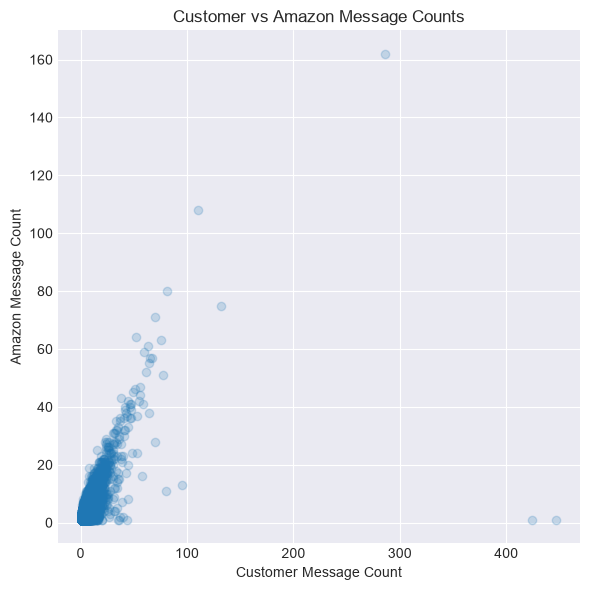

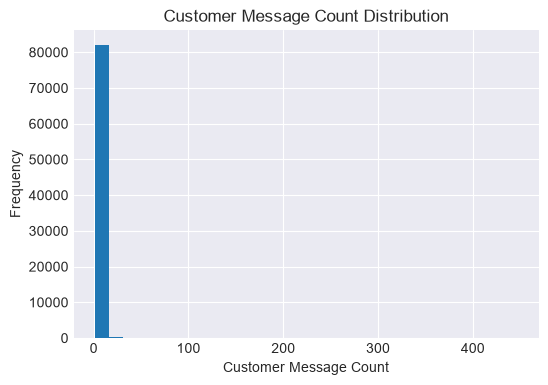

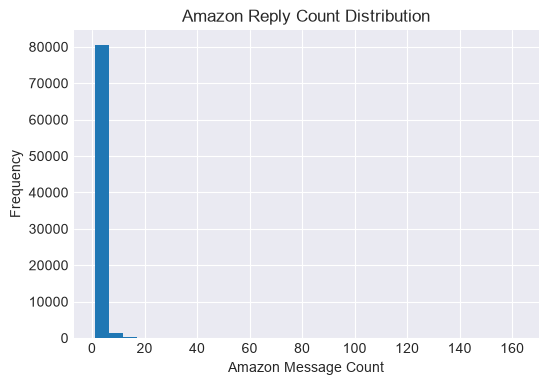

In [12]:
# Section 4 — Customer vs Amazon Message Analysis
print('📊 Customer vs Amazon message statistics:')
print(df[['customer_message_count','amazon_message_count']].describe())

plt.figure(figsize=(6,6))
plt.scatter(df['customer_message_count'], df['amazon_message_count'], alpha=0.2)
plt.title('Customer vs Amazon Message Counts')
plt.xlabel('Customer Message Count')
plt.ylabel('Amazon Message Count')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'customer_vs_amazon_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['customer_message_count'], bins=30)
plt.title('Customer Message Count Distribution')
plt.xlabel('Customer Message Count')
plt.ylabel('Frequency')
plt.savefig(ASSETS_DIR / 'customer_message_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['amazon_message_count'], bins=30)
plt.title('Amazon Reply Count Distribution')
plt.xlabel('Amazon Message Count')
plt.ylabel('Frequency')
plt.savefig(ASSETS_DIR / 'amazon_message_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 5 — Conversation Size Analysis
Create `conversation_word_count` and `conversation_character_count`.

       conversation_word_count  conversation_character_count
count             82556.000000                  82556.000000
mean                 92.740952                    587.687182
std                 109.829920                    664.613660
min                   5.000000                     44.000000
25%                  42.000000                    275.000000
50%                  66.000000                    422.000000
75%                 112.000000                    697.000000
max                8199.000000                  50491.000000


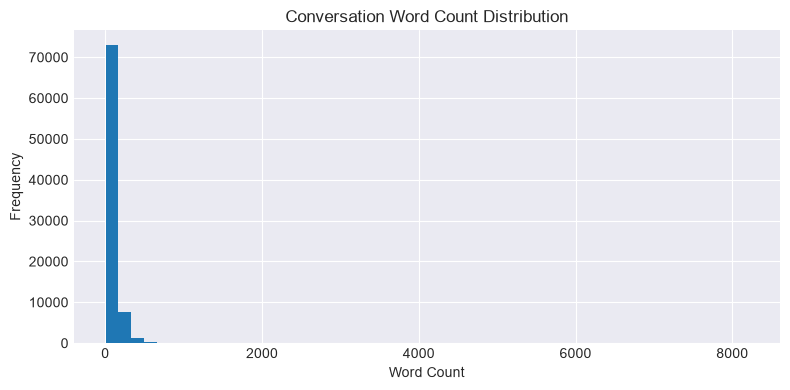


Top longest conversations by words:
      conversation_id  conversation_word_count
78         AMZ_000079                     8199
50240      AMZ_050241                     7360
13097      AMZ_013098                     4651
346        AMZ_000347                     3983
30132      AMZ_030133                     3889
27715      AMZ_027716                     3744
7456       AMZ_007457                     3380
36820      AMZ_036821                     3209
3077       AMZ_003078                     3077
8550       AMZ_008551                     2995

Top shortest conversations by words:
      conversation_id  conversation_word_count
7780       AMZ_007781                        5
19275      AMZ_019276                        5
59138      AMZ_059139                        5
80169      AMZ_080170                        5
54429      AMZ_054430                        5
32056      AMZ_032057                        5
2962       AMZ_002963                        5
60363      AMZ_060364           

In [13]:
# Section 5 — Conversation Size Analysis
# word and character counts
df['conversation_word_count'] = df['conversation'].str.split().str.len()
df['conversation_character_count'] = df['conversation'].str.len()
print(df[['conversation_word_count','conversation_character_count']].describe())

plt.figure(figsize=(8,4))
plt.hist(df['conversation_word_count'], bins=50)
plt.title('Conversation Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'conversation_word_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop longest conversations by words:')
print(df.sort_values('conversation_word_count', ascending=False).head(10)[['conversation_id','conversation_word_count']])

print('\nTop shortest conversations by words:')
print(df.sort_values('conversation_word_count', ascending=True).head(10)[['conversation_id','conversation_word_count']])

## Section 6 — Extract Customer Messages Only
Write and apply `extract_customer_messages` to create `customer_text`.

In [14]:
# Section 6 — Extract Customer Messages Only
from src.preprocessing.text_cleaning import extract_customer_messages

print('✅ Extracting customer messages...')
df['customer_text'] = df['conversation'].apply(extract_customer_messages)

print('\nBefore / After Example:')
for _, row in df[['conversation','customer_text']].head(3).iterrows():
    print('--- ORIGINAL CONVERSATION ---')
    print(row['conversation'])
    print('\n--- EXTRACTED CUSTOMER TEXT ---')
    print(row['customer_text'])
    print('\n')

ModuleNotFoundError: No module named 'src'

## Section 7 — Language Detection
Detect languages on a deterministic sample of 2000 conversations and plot distribution.

In [ ]:
# Section 7 — Language Detection
from langdetect import DetectorFactory, detect
import random

DetectorFactory.seed = 0
random.seed(0)

sample = df['customer_text'].dropna().sample(min(2000, len(df)), random_state=0)
print(f'📦 Detecting language for {len(sample)} conversations')

langs = [detect(text) if text.strip() else 'unknown' for text in sample]

import collections
freq = collections.Counter(langs)
lang_df = pd.DataFrame(freq.most_common(), columns=['language','count'])
lang_df['percent'] = lang_df['count'] / lang_df['count'].sum() * 100

plt.figure(figsize=(8,4))
plt.bar(lang_df['language'], lang_df['count'])
plt.title('Language Distribution (sample)')
plt.xlabel('Language')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

display(lang_df)

## Section 8 — URL / Mention / Emoji Analysis
Count URLs, mentions, emojis, hashtags in customer_text.

In [ ]:
# Section 8 — URL / Mention / Emoji Analysis
import re
from collections import Counter

url_re = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
mention_re = re.compile(r"@\w+", flags=re.IGNORECASE)
emoji_re = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\u2600-\u26FF\u2700-\u27BF]+", flags=re.UNICODE)
hashtag_re = re.compile(r"#\w+", flags=re.IGNORECASE)

stats = {
    'urls': df['customer_text'].fillna('').apply(lambda t: len(url_re.findall(t))).sum(),
    'mentions': df['customer_text'].fillna('').apply(lambda t: len(mention_re.findall(t))).sum(),
    'emojis': df['customer_text'].fillna('').apply(lambda t: len(emoji_re.findall(t))).sum(),
    'hashtags': df['customer_text'].fillna('').apply(lambda t: len(hashtag_re.findall(t))).sum(),
}

print('📊 URL / Mention / Emoji / Hashtag counts:')
print(stats)

# Top mentions
mentions = Counter()
for t in df['customer_text'].dropna():
    mentions.update(mention_re.findall(t))
print('\nTop mentions:')
print(mentions.most_common(10))

# Explain removal rationale
print('\nURLs and mentions will be removed in final cleaning as they are identifiers or noisy links that do not contribute to intent semantics.')

## Section 9 — Keyword Analysis
Use `CountVectorizer` to find top keywords (English stopwords).

In [ ]:
# Section 9 — Keyword Analysis
from sklearn.feature_extraction.text import CountVectorizer

print('📊 Building CountVectorizer top keywords...')
vectorizer = CountVectorizer(stop_words='english', max_features=100)
X = vectorizer.fit_transform(df['customer_text'].fillna(''))
sum_words = X.sum(axis=0)
words_freq = [(word, int(sum_words[0, idx])) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

top30 = words_freq[:30]
top_df = pd.DataFrame(top30, columns=['keyword','count'])

plt.figure(figsize=(8,6))
plt.barh(top_df['keyword'][::-1], top_df['count'][::-1])
plt.title('Top Keywords')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'top_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

# Save CSV to assets
(ASSETS_DIR).mkdir(parents=True, exist_ok=True)
(top_df).to_csv(ASSETS_DIR / 'top_keywords.csv', index=False)

display(top_df)

## Section 10 — Build Clean Customer Corpus
Use `aggressive_clean` to produce `customer_text_clean`.

In [ ]:
# Section 10 — Build Clean Customer Corpus
from src.preprocessing.text_cleaning import aggressive_clean

print('✅ Cleaning customer text...')
df['customer_text_clean'] = df['customer_text'].apply(aggressive_clean)

print('\nSample before / after:')
for i in range(3):
    print('---')
    print('Original:', df.loc[i,'customer_text'])
    print('Cleaned :', df.loc[i,'customer_text_clean'])

## Section 11 — Dataset Quality Checks
Validate duplicates and empties.

In [ ]:
# Section 11 — Dataset Quality Checks
checks = {
    'duplicate_conversation_id': not df['conversation_id'].duplicated().any(),
    'empty_customer_text': not df['customer_text'].isna().any(),
    'empty_customer_text_clean': not df['customer_text_clean'].isna().any(),
    'duplicate_customer_text_clean': not df['customer_text_clean'].duplicated().any(),
    'short_conversations': (df['customer_text_clean'].str.split().str.len() < 3).sum() == 0,
}

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")


## Section 12 — Save Clean Dataset
Save `amazon_conversations_clean.csv` including new columns.

In [ ]:
# Section 12 — Save Clean Dataset
output_path = DATA_DIR / 'processed' / 'amazon_conversations_clean.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print('💾 Saved clean dataset to', output_path)

## Section 13 — Generate EDA Report
Automatically generate `report/phase3_eda_summary.md`.

In [ ]:
# Section 13 — Generate EDA Report
report_path = REPORT_DIR / 'phase3_eda_summary.md'
report_path.parent.mkdir(parents=True, exist_ok=True)

with report_path.open('w', encoding='utf8') as f:
    f.write('# Phase 3 — EDA Summary\n\n')
    f.write('## Dataset Summary\n')
    f.write(f'- total conversations: {len(df):,}\n')
    f.write(f'- average messages: {df["message_count"].mean():.2f}\n')
    f.write(f'- median messages: {df["message_count"].median():.2f}\n')
    f.write(f'- max messages: {df["message_count"].max()}\n')
    f.write('\n## Top Keywords\n')
    for k,v in top_df.head(10).itertuples(index=False):
        f.write(f'- {k}: {v}\n')
    f.write('\n## Key Observations\n')
    obs = [
        'Delivery and order issues dominate customer messages.',
        'Refund and payment queries are common.',
        'Account and login problems appear frequently.',
        'Prime Video streaming errors are a notable cluster.',
        'Missing or damaged package reports are present.',
        'There are multiple languages in the dataset; multilingual support required.',
        'Conversation lengths are skewed; many short interactions and some long threads.',
        'URLs and mentions are common and will be removed for intent discovery.',
    ]
    for o in obs:
        f.write(f'- {o}\n')

print('💾 EDA report written to', report_path)

## Section 14 — Interview Notes

### Insights for Intent Discovery
- Delivery/order issues dominate.
- Refund/payment conversations.
- Account/login problems.
- Prime Video streaming issues.
- Damaged or missing packages.
- Multilingual conversations exist.
- Conversation lengths are highly skewed.
- Short interactions are common, but long threads exist.

In [ ]:
# Final Validation Cell — Confirm outputs exist
expected_files = [
    ASSETS_DIR / 'conversation_length_distribution.png',
    ASSETS_DIR / 'customer_vs_amazon_scatter.png',
    ASSETS_DIR / 'customer_message_histogram.png',
    ASSETS_DIR / 'amazon_message_histogram.png',
    ASSETS_DIR / 'conversation_word_distribution.png',
    ASSETS_DIR / 'language_distribution.png',
    ASSETS_DIR / 'top_keywords.png',
    ASSETS_DIR / 'top_keywords.csv',
    DATA_DIR / 'processed' / 'amazon_conversations_clean.csv',
    REPORT_DIR / 'phase3_eda_summary.md',
    DATA_PATH,
]

print('\n=== Validation Results ===')
all_ok = True
for p in expected_files:
    exists = p.exists()
    print(f"{p}: {'PASS' if exists else 'MISSING'}")
    if not exists:
        all_ok = False

print('\nOverall:', 'PASS' if all_ok else 'FAIL')